In [15]:
import numpy as np

data = np.load("BATCH1.npz", allow_pickle=True)

print("keys:", data.files)

for k in data.files:
    print("\n====", k, "====")
    print("shape:", data[k].shape)
    print("dtype:", data[k].dtype)

keys: ['ppg', 'faces', 'labels', 'clip_id']

==== ppg ====
shape: (1920, 1, 250)
dtype: float32

==== faces ====
shape: (1920, 16, 3, 64, 64)
dtype: float32

==== labels ====
shape: (1920,)
dtype: int64

==== clip_id ====
shape: (1920,)
dtype: int64


# EDA

In [17]:
import numpy as np
import pandas as pd

clip_ids = np.asarray(data["clip_id"]).reshape(-1)
labels = np.asarray(data["labels"]).reshape(-1)

assert len(clip_ids) == len(labels), "长度不一致"

meta_df = pd.DataFrame({
    "clip_id": clip_ids,
    "label": labels
})

meta_df.head()

,clip_id,label
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


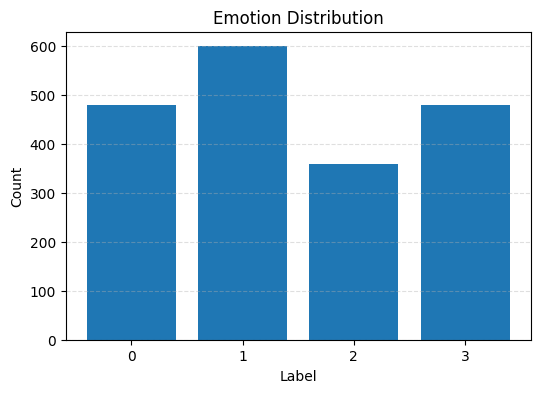

label
0    480
1    600
2    360
3    480
Name: count, dtype: int64


In [18]:
import matplotlib.pyplot as plt

label_counts = meta_df["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Emotion Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

print(label_counts)

In [19]:
unique_clips = meta_df["clip_id"].unique()

print("Number of CLIPs:", len(unique_clips))
print("CLIP IDs:", unique_clips)

Number of CLIPs: 16
CLIP IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


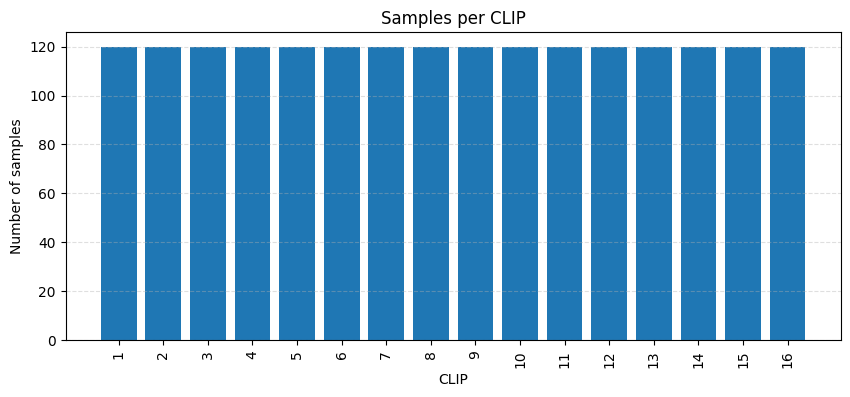

count     16.0
mean     120.0
std        0.0
min      120.0
25%      120.0
50%      120.0
75%      120.0
max      120.0
Name: count, dtype: float64


In [20]:
clip_counts = meta_df["clip_id"].value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.bar(clip_counts.index.astype(str), clip_counts.values)
plt.title("Samples per CLIP")
plt.xlabel("CLIP")
plt.ylabel("Number of samples")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

print(clip_counts.describe())

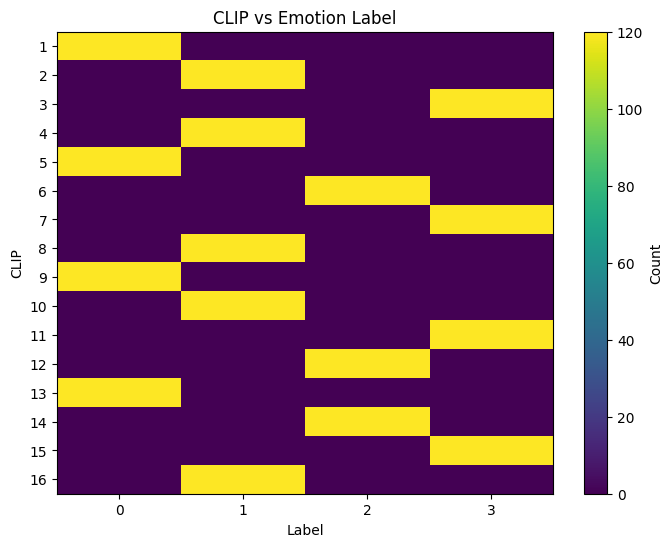

In [21]:
cross_tab = pd.crosstab(meta_df["clip_id"], meta_df["label"])

plt.figure(figsize=(8,6))
plt.imshow(cross_tab.values, aspect="auto")
plt.colorbar(label="Count")

plt.title("CLIP vs Emotion Label")
plt.xlabel("Label")
plt.ylabel("CLIP")

plt.xticks(range(len(cross_tab.columns)), cross_tab.columns)
plt.yticks(range(len(cross_tab.index)), cross_tab.index)

plt.show()